In [247]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,f1_score,classification_report

In [248]:
# LOADING THE DATA
df = pd.read_csv('/dataset.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [249]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [250]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [251]:
df.shape

(768, 9)

In [252]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [253]:
df.duplicated().sum()

np.int64(0)

In [254]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [255]:
# Here 0 means NON-DIABETEIC and 1 means DIABETEIC
counts=df['Outcome'].value_counts()
counts

,count
Outcome,
0,500
1,268


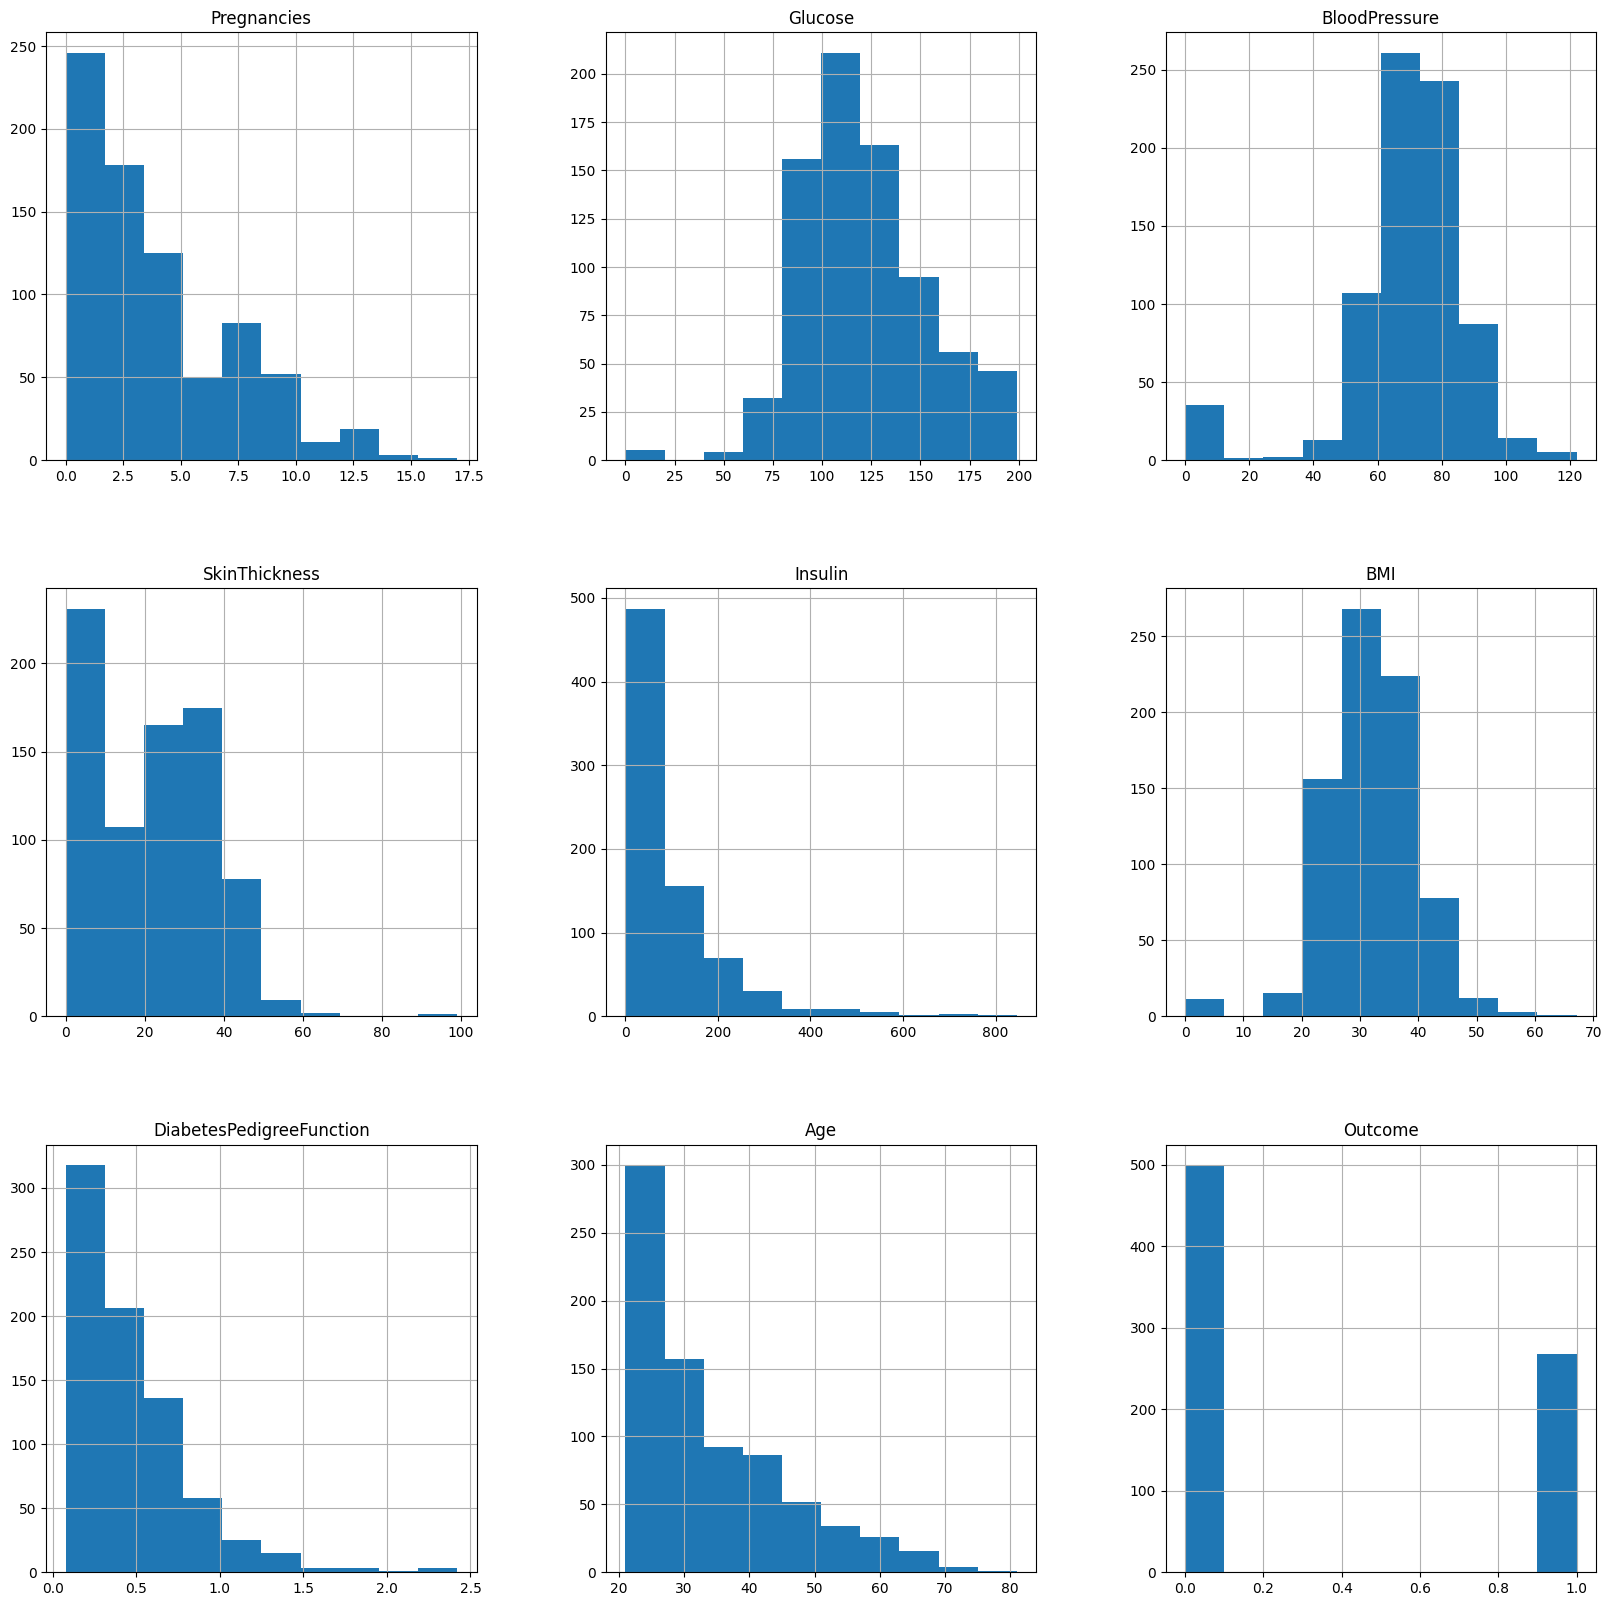

In [256]:
#plotiing histogram
z=df.hist(figsize=(20,20))

(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

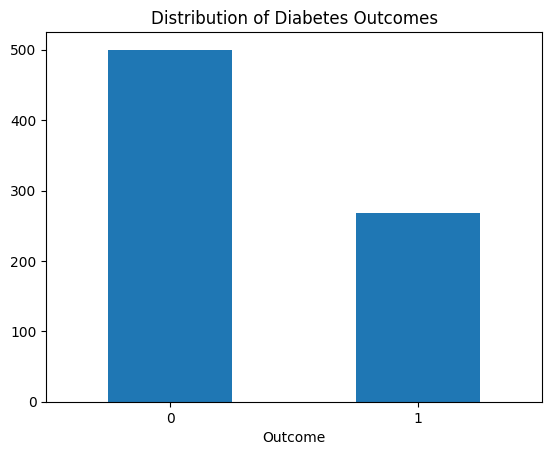

In [257]:
df['Outcome'].value_counts().plot(kind="bar", title='Distribution of Diabetes Outcomes')
plt.xticks(rotation=0)

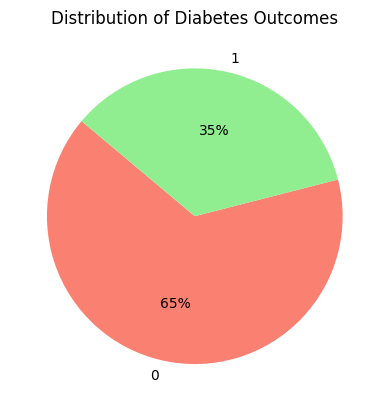

In [258]:
plt.pie(counts,
        labels=counts.index,
        autopct='%1.0f%%',
        colors=['salmon','lightgreen'],
        startangle=140)
plt.title('Distribution of Diabetes Outcomes')
plt.show()

In [259]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [260]:
# SEPARATING THE DATA
X = df.drop(columns='Outcome',axis=1)
Y = df['Outcome']

In [261]:
print(X)
print(Y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [262]:
# DATA STANDARDIZATION
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [263]:
print(X_scaled)
print(Y)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]
0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [264]:
# SPLITTING DATA INTO TRAINING AND TESTING DATA
X_train,X_test,Y_train,Y_test = train_test_split(X_scaled,Y,test_size=0.2,stratify=Y,random_state=2)

In [265]:
print(X_scaled.shape,X_train.shape,X_test.shape)

(768, 8) (614, 8) (154, 8)


In [266]:
# TRAINING THE MODEL
model = SVC(kernel='linear')

In [267]:
model.fit(X_train,Y_train)

SVC(kernel='linear')

In [268]:
# evalaution of model

Y_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train_prediction,Y_train)

In [269]:
print('Accuracy score of the train data : ', training_data_accuracy)

Accuracy score of the train data :  0.7866449511400652


In [270]:
Y_test_prediction = model.predict(X_test)
testing_data_accuracy = accuracy_score(Y_test_prediction,Y_test)

In [271]:
print('Accuracy score of the test data : ', testing_data_accuracy)

Accuracy score of the test data :  0.7727272727272727


In [272]:
models={
    "Logistic Regression": LogisticRegression(),
    "KNN" : KNeighborsClassifier(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Naive Bayes" : GaussianNB(),
    "Support Vector Machine" : SVC(kernel='linear')
}

In [273]:
result=[]

In [274]:
for name, model in models.items():
  model.fit(X_train,Y_train)
  y_pred=model.predict(X_test)
  acc=accuracy_score(Y_test,y_pred)
  f1=f1_score(Y_test,y_pred)
  result.append({
      'model':name,
      'accuracy':round(acc,4),
      'f1 score' : round(f1,4)
  })

In [275]:
result

[{'model': 'Logistic Regression', 'accuracy': 0.7597, 'f1 score': 0.6022},
 {'model': 'KNN', 'accuracy': 0.7208, 'f1 score': 0.5275},
 {'model': 'Decision Tree', 'accuracy': 0.6948, 'f1 score': 0.5155},
 {'model': 'Naive Bayes', 'accuracy': 0.7727, 'f1 score': 0.6392},
 {'model': 'Support Vector Machine', 'accuracy': 0.7727, 'f1 score': 0.6154}]

In [276]:
import joblib
joblib.dump(models [ 'Support Vector Machine' ], 'SVM_diabetes.pkl')
joblib.dump(scaler, 'diabetes_scaler.pkl')
joblib.dump(X.columns.tolist(), 'diabetes_columns.pkl')

['diabetes_columns.pkl']